In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as colors
from matplotlib.cm import ScalarMappable
%matplotlib inline

In [2]:
result_figure_path = "../results/figures/normalized_mean_with_eco/"

In [3]:
statistic = pd.read_table("../results/processedData/normalized_mean_with_eco/ttest_all_statistic.table", delimiter=" ")
pvalue = pd.read_table("../results/processedData/normalized_mean_with_eco/ttest_all_pvalue.table", delimiter=" ")
query_number = pd.read_table("../results/processedData/normalized_mean_with_eco/ttest_all_query_number.table", delimiter=" ")
target_number = pd.read_table("../results/processedData/normalized_mean_with_eco/ttest_all_target_number.table", delimiter=" ")

In [4]:
statistic = statistic.iloc[0:-1]
pvalue = pvalue.iloc[0:-1]
query_number = query_number[0:-1]

In [5]:
pvalue

,Wild,Cvbct,Conventionalized,3OHC12,Eco1KD_B8
Ec_Head,3.691189e-01,7.266393e-05,2.119733e-05,5.784648e-03,2.888337e-03
En_Head,2.756221e-01,6.659744e-01,6.926879e-01,2.198934e-02,4.411444e-02
Ec_BodyCol.SC,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
I_ISC,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
Ec_Peduncle,6.081063e-02,6.727735e-05,9.751575e-06,1.013744e-01,4.874531e-02
Ec_Tentacle,1.289804e-03,5.866085e-08,1.861903e-07,3.368824e-02,4.119917e-04
I_FemGC,1.248877e-03,1.224229e-02,8.745384e-05,9.396441e-01,4.011503e-06
Ec_BasalDisk,3.848334e-02,3.503591e-01,9.343268e-06,2.713040e-02,8.406160e-23
I_Neuro,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
I_EarlyNem,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [6]:
statistic

,Wild,Cvbct,Conventionalized,3OHC12,Eco1KD_B8
Ec_Head,1,5,5,3,-3
En_Head,-1,0,0,3,-2
Ec_BodyCol.SC,0,0,0,0,0
I_ISC,0,0,0,0,0
Ec_Peduncle,-2,5,-6,-2,-2
Ec_Tentacle,4,7,7,2,-4
I_FemGC,3,-3,4,0,5
Ec_BasalDisk,-2,1,-5,-2,-13
I_Neuro,0,0,0,0,0
I_EarlyNem,0,0,0,0,0


In [6]:
statistic = statistic.rename(columns={'Eco1KD_B8':'Eco1KD'})
pvalue = pvalue.rename(columns={'Eco1KD_B8':'Eco1KD'})
target_number = target_number.rename(columns={'Eco1KD_B8':'Eco1KD'})

In [7]:
# Conventionalized, cvbt, 3OHAHL, EcoKD
cols = ['Wild', 'Cvbct', 'Conventionalized', '3OHC12',"Eco1KD"]
l_supercluster_statistic = statistic.loc[statistic.index.str.contains("^L_*")][cols]
supercluster_statistic = statistic.loc[statistic.index.str.contains("^C_*")][cols]
ectoderm_statistic = statistic.loc[statistic.index.str.contains("^Ec_*")][cols]
endoderm_statistic = statistic.loc[statistic.index.str.contains("^En_*")][cols]
interstitial_statistic = statistic.loc[statistic.index.str.contains("^I_*")][cols]

l_supercluster_pvalue = pvalue.loc[pvalue.index.str.contains("^L_*")][cols]
supercluster_pvalue = pvalue.loc[pvalue.index.str.contains("^C_*")][cols]
ectoderm_pvalue = pvalue.loc[pvalue.index.str.contains("^Ec_*")][cols]
endoderm_pvalue = pvalue.loc[pvalue.index.str.contains("^En_*")][cols]
interstitial_pvalue = pvalue.loc[pvalue.index.str.contains("^I_*")][cols]


l_supercluster_query = query_number.loc[query_number.index.str.contains("^L_*")]
supercluster_query = query_number.loc[query_number.index.str.contains("^C_*")]
ectoderm_query = query_number.loc[query_number.index.str.contains("^Ec_*")]
endoderm_query = query_number.loc[query_number.index.str.contains("^En_*")]
interstitial_query = query_number.loc[query_number.index.str.contains("^I_*")]

sliced_targets = target_number[cols]

In [25]:
ectoderm_statistic

,Wild,Cvbct,Conventionalized,3OHC12,Eco1KD
Ec_Head,1,5,5,3,-3
Ec_BodyCol.SC,0,0,0,0,0
Ec_Peduncle,-2,5,-6,-2,-2
Ec_Tentacle,4,7,7,2,-4
Ec_BasalDisk,-2,1,-5,-2,-13


In [10]:
ectoderm_query["V1"]

Ec_Head          29
Ec_BodyCol.SC     3
Ec_Peduncle      25
Ec_Tentacle      32
Ec_BasalDisk     89
Name: V1, dtype: int64

In [8]:
class MidpointNormalize(colors.Normalize):
    """Normalise the colorbar."""
    def __init__(self, vmin=None, vmax=None, midpoint=None, clip=False):
        self.midpoint = midpoint
        colors.Normalize.__init__(self, vmin, vmax, clip)

    def __call__(self, value, clip=None):
        x, y = [self.vmin, self.midpoint, self.vmax], [0, 0.5, 1]
        return np.ma.masked_array(np.interp(value, x, y), np.isnan(value))

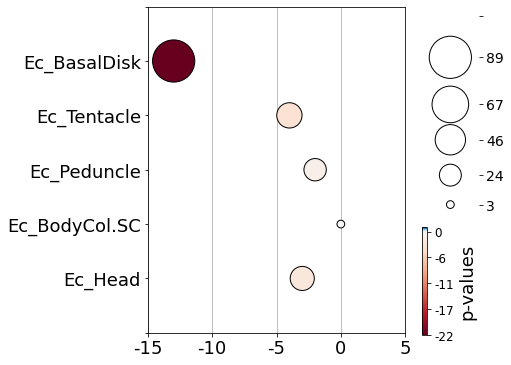

In [94]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(8,6), sharey=False,gridspec_kw={"width_ratios":[3,1]})

yticks = list(range(len(ectoderm_statistic.index)))
yticks.insert(0,-1)
yticks.append(len(yticks)-1)

ylabel = list(ectoderm_statistic.index)
ylabel.insert(0,"")
ylabel.append("")

pvals = abs(np.log10(np.array(ectoderm_pvalue["Eco1KD"]))) * np.sign(ectoderm_statistic["Eco1KD"])
min_pval = min(pvals)
max_pval = max(pvals)
if min_pval == 0:
    min_pval = min_pval -1
if max_pval == 0:
    max_pval = max_pval + 1
    
norm = colors.TwoSlopeNorm(vmin=min_pval, vcenter=0, vmax=max_pval)

ax1.scatter(y=range(len(ectoderm_statistic.index)),x=ectoderm_statistic["Eco1KD"],
            marker="o", s=ectoderm_query["V1"]*20, edgecolor="black",c=pvals, norm=norm, cmap="RdBu", zorder=2)
ax1.set_yticks(yticks)
ax1.set_yticklabels(ylabel, fontsize=18)
ax1.set_xticks([-15,-10,-5,0,5])
ax1.set_xticklabels([-15,-10,-5,0,5],fontsize=18)
ax1.grid(axis="x",zorder=0)

#abs(np.log10(pvalue)) * np.sign(statistic)

#norm = MidpointNormalize(min(pvals.min()), max(pvals.max()), 0.)

cbar = fig.colorbar(ScalarMappable(norm=norm, cmap="RdBu"), ax=ax1, pad=0.005)
cbar.set_label("p-values", fontsize=18, labelpad=5)
custom_ticks = np.linspace(min(pvals), max(pvals), num=5) 
cbar.set_ticks(custom_ticks)
cbar.ax.set_position([0.6,0.12,0.08,0.25])
cbar.ax.yaxis.set_tick_params(labelsize=12)
cbar.set_ticklabels([f"{tick:.0f}" for tick in custom_ticks]) 

sorted_markersize = np.linspace(min(ectoderm_query["V1"]),max(ectoderm_query["V1"]),5, dtype=int)*20 #np.sort(endoderm_query["V1"]*20)
sorted_markersize = np.append(sorted_markersize,0)
yticklabels = np.append(np.linspace(min(endoderm_query["V1"]),max(ectoderm_query["V1"]),5, dtype=int),"") #np.append(np.sort(endoderm_query["V1"]),"")




ax2.set_position([0.6,0.4,0.1,0.48])
ax2.scatter(x=[0.5 for i in yticklabels],
            y=[0,0.5,1.1,1.7,2.5,3.2],
            s=sorted_markersize,c="white",
            edgecolor="black")

ax2.set_xlim(0,1)
ax2.set_yticks([0,0.5,1.1,1.7,2.5,3.2])
ax2.set_yticklabels(labels=np.append(np.linspace(min(ectoderm_query["V1"]),max(ectoderm_query["V1"]),5, dtype=int),""),fontsize=14)
ax2.yaxis.tick_right()
ax2.set_xticks([])
for spine in ax2.spines.values():
    spine.set_visible(False)

plt.savefig("../results/figures/normalized_mean_with_eco/ectoderm_eco.svg")
#ax1.sxlabel("Hypergeometric t-value", fontsize=14, labelpad=20)

In [78]:
ectoderm_statistic

,Wild,Cvbct,Conventionalized,3OHC12,Eco1KD
Ec_Head,1,5,5,3,-3
Ec_BodyCol.SC,0,0,0,0,0
Ec_Peduncle,-2,5,-6,-2,-2
Ec_Tentacle,4,7,7,2,-4
Ec_BasalDisk,-2,1,-5,-2,-13


In [12]:
max_pval

-0.7950430454421706

In [13]:
min_pval

-1.7512520371759275

In [16]:
yticklabels

array(['9', '10', '17', '17', ''], dtype='<U21')

In [53]:
np.linspace(0,max(endoderm_query["V1"]),10, dtype=int)

array([ 0,  1,  3,  5,  7,  9, 11, 13, 15, 17])

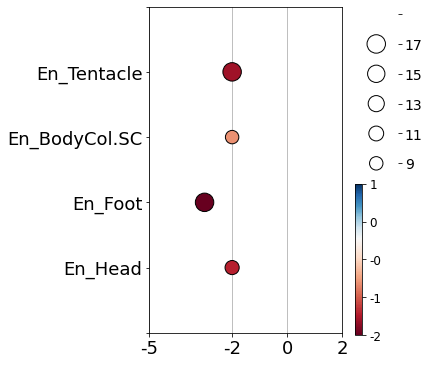

In [93]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(6,6), sharey=False,gridspec_kw={"width_ratios":[3,1]})

yticks = list(range(len(endoderm_statistic.index)))
yticks.insert(0,-1)
yticks.append(len(yticks)-1)

ylabel = list(endoderm_statistic.index)
ylabel.insert(0,"")
ylabel.append("")

pvals = abs(np.log10(np.array(endoderm_pvalue["Eco1KD"]))) * np.sign(endoderm_statistic["Eco1KD"])
min_pval = min(pvals)
max_pval = max(pvals)
if min_pval == 0:
    min_pval = min_pval -1
if max_pval == 0:
    max_pval = max_pval + 1
    
norm = colors.TwoSlopeNorm(vmin=min_pval, vcenter=0, vmax=1)

ax1.scatter(y=range(len(endoderm_statistic.index)),x=endoderm_statistic["Eco1KD"],
            marker="o", s=endoderm_query["V1"]*20, edgecolor="black",c=pvals, norm=norm, cmap="RdBu", zorder=2)
ax1.set_yticks(yticks)
ax1.set_yticklabels(ylabel, fontsize=18)
ax1.set_xticks([-5,-2,0,2])
ax1.set_xticklabels([-5,-2,0,2],fontsize=18)
ax1.grid(axis="x",zorder=0)

#abs(np.log10(pvalue)) * np.sign(statistic)

#norm = MidpointNormalize(min(pvals.min()), max(pvals.max()), 0.)

cbar = fig.colorbar(ScalarMappable(norm=norm, cmap="RdBu"), ax=ax1, pad=0.005)
#cbar.set_label("p-values", fontsize=18, labelpad=5)
custom_ticks = np.linspace(min_pval, 1, num=5) 
cbar.set_ticks(custom_ticks)
cbar.ax.yaxis.set_tick_params(labelsize=12)
cbar.ax.set_position([0.6,0.12,0.08,0.35])
cbar.set_ticklabels([f"{tick:.0f}" for tick in custom_ticks]) 

sorted_markersize = np.linspace(min(endoderm_query["V1"]),max(endoderm_query["V1"]),5, dtype=int)*20 #np.sort(endoderm_query["V1"]*20)
sorted_markersize = np.append(sorted_markersize,0)
yticklabels = np.append(np.linspace(min(endoderm_query["V1"]),max(endoderm_query["V1"]),5, dtype=int),"") #np.append(np.sort(endoderm_query["V1"]),"")



ax2.set_position([0.6,0.5,0.1,0.38])
ax2.scatter(x=[0.5 for i in yticklabels],
            y=[0,0.5,1,1.5,2,2.5],
            s=sorted_markersize,c="white",
            edgecolor="black")

ax2.set_xlim(0,1)
ax2.set_yticks([0,0.5,1,1.5,2,2.5])
ax2.set_yticklabels(labels=np.append(np.linspace(min(endoderm_query["V1"]),max(endoderm_query["V1"]),5, dtype=int),""),fontsize=14)
ax2.yaxis.tick_right()
ax2.set_xticks([])
for spine in ax2.spines.values():
    spine.set_visible(False)

plt.savefig("../results/figures/normalized_mean_with_eco/endoderm_eco.svg")
#ax1.sxlabel("Hypergeometric t-value", fontsize=14, labelpad=20)

In [73]:
endoderm_query

,V1
En_Head,10
En_Foot,17
En_BodyCol.SC,9
En_Tentacle,17


In [58]:
yticklabels

array([ 0,  4,  8, 12, 17])

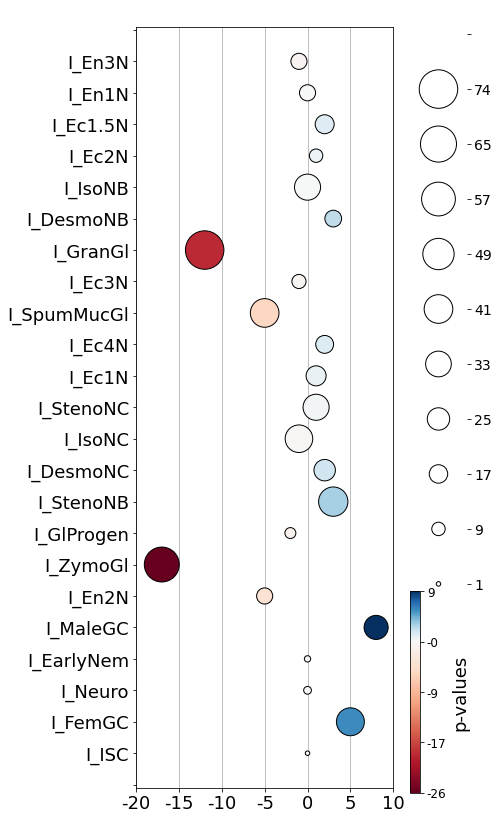

In [92]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(8,14), sharey=False,gridspec_kw={"width_ratios":[3,1]})

yticks = list(range(len(interstitial_statistic.index)))
yticks.insert(0,-1)
yticks.append(len(yticks)-1)

ylabel = list(interstitial_statistic.index)
ylabel.insert(0,"")
ylabel.append("")

pvals = abs(np.log10(np.array(interstitial_pvalue["Eco1KD"]))) * np.sign(interstitial_statistic["Eco1KD"])
min_pval = min(pvals)
max_pval = max(pvals)
if min_pval == 0:
    min_pval = min_pval -1
if max_pval == 0:
    max_pval = max_pval + 1
    
norm = colors.TwoSlopeNorm(vmin=min_pval, vcenter=0, vmax=max_pval)

ax1.scatter(y=range(len(interstitial_statistic.index)),x=interstitial_statistic["Eco1KD"],
            marker="o", s=interstitial_query["V1"]*20, edgecolor="black",c=pvals, norm=norm, cmap="RdBu", zorder=2)
ax1.set_yticks(yticks)
ax1.set_yticklabels(ylabel, fontsize=18)
ax1.set_xticks([-20,-15,-10,-5,0,5,10])
ax1.set_xticklabels([-20,-15,-10,-5,0,5,10],fontsize=18)
ax1.grid(axis="x",zorder=0)

#abs(np.log10(pvalue)) * np.sign(statistic)

#norm = MidpointNormalize(min(pvals.min()), max(pvals.max()), 0.)

cbar = fig.colorbar(ScalarMappable(norm=norm, cmap="RdBu"), ax=ax1, pad=0.005)
cbar.set_label("p-values", fontsize=18, labelpad=5)
custom_ticks = np.linspace(min(pvals), max(pvals), num=5) 
cbar.set_ticks(custom_ticks)
cbar.ax.set_position([0.6,0.12,0.08,0.2])
cbar.ax.yaxis.set_tick_params(labelsize=12)
cbar.set_ticklabels([f"{tick:.0f}" for tick in custom_ticks]) 

sorted_markersize = np.linspace(min(interstitial_query["V1"]),max(interstitial_query["V1"]),10, dtype=int)*20 #np.sort(endoderm_query["V1"]*20)
sorted_markersize = np.append(sorted_markersize,0)
yticklabels = np.append(np.linspace(min(interstitial_query["V1"]),max(interstitial_query["V1"]),10, dtype=int),"") #np.append(np.sort(endoderm_query["V1"]),"")
ax2.set_position([0.6,0.3,0.1,0.6])

ax2.scatter(x=[0.5 for i in yticklabels],
            y=[0,1,2,3,4,5,6,7,8,9,10],
            s=sorted_markersize,c="white", 
            edgecolor="black")

ax2.set_xlim(0,1)
ax2.set_yticks([0,1,2,3,4,5,6,7,8,9,10])
ax2.set_yticklabels(labels=np.append(np.linspace(min(interstitial_query["V1"]),max(interstitial_query["V1"]),10, dtype=int),""),fontsize=14)
ax2.yaxis.tick_right()
ax2.set_xticks([])
for spine in ax2.spines.values():
    spine.set_visible(False)

plt.savefig("../results/figures/normalized_mean_with_eco/interstitial_eco.svg")
#ax1.sxlabel("Hypergeometric t-value", fontsize=14, labelpad=20)

In [89]:
interstitial_query

,V1
I_ISC,1
I_FemGC,39
I_Neuro,3
I_EarlyNem,2
I_MaleGC,29
I_En2N,13
I_ZymoGl,61
I_GlProgen,6
I_StenoNB,43
I_DesmoNC,23


In [43]:
len(np.append(np.sort(interstitial_query["V1"]),""))

24

In [44]:
[0,0.5,
                1,1.5,
                2.5,3,
                3.5,4,4.5,5,5.5,6,6.5,7,7.5,8,8.5,9,9.5,10,10.5,11,11.5,12]

[0,
 0.5,
 1,
 1.5,
 2.5,
 3,
 3.5,
 4,
 4.5,
 5,
 5.5,
 6,
 6.5,
 7,
 7.5,
 8,
 8.5,
 9,
 9.5,
 10,
 10.5,
 11,
 11.5,
 12]

In [29]:
len([0,0.5,1,1.5,2.5,3,3.5,4,4.5,5,5.5,6,6.5,7,7.5,8,8.5,9,9.5,10,10.5,11,11.5])

23

In [31]:
len(yticklabels)

24

In [28]:
len(interstitial_statistic)/2

11.5

In [118]:
def plot_heatmap_of_clusterings(statistic:pd.DataFrame,
                                pvalue:pd.DataFrame,
                                query_number:pd.DataFrame,
                                target_number:pd.DataFrame,
                               title:str,
                               yaxis:str,
                               xaxis:str,
                               output_filename:str,
                               size=(14,16),
                               fonts=15,
                               padx=0.05):
    try:
        # set the colormap and centre the colorbar
        class MidpointNormalize(colors.Normalize):
            """Normalise the colorbar."""
            def __init__(self, vmin=None, vmax=None, midpoint=None, clip=False):
                self.midpoint = midpoint
                colors.Normalize.__init__(self, vmin, vmax, clip)

            def __call__(self, value, clip=None):
                x, y = [self.vmin, self.midpoint, self.vmax], [0, 0.5, 1]
                return np.ma.masked_array(np.interp(value, x, y), np.isnan(value))

        print("[*] Adjusting statistic values to pvalue ...\n[*] Setting values with pval > 0.05 to 0 ...")
        for i in range(statistic.shape[0]):
            for j in range(statistic.shape[1]):
                if pvalue.iloc[i, j] > 0.05:
                    statistic.iloc[i,j] = 0
        print("[*] DONE pvalue adjustment")
        print("[*] Start plotting ...")
        # Create a figure and axes
        fig, ax = plt.subplots(figsize=size)

        cmap = "RdBu"
        pcolors = pd.DataFrame(abs(np.log10(pvalue)) * np.sign(statistic))
        ax2 = ax.twinx()
        #ax3 = ax.twiny()
        #heatmap3 = ax3.imshow(pcolors, cmap=cmap, aspect='auto', norm=MidpointNormalize(min(pcolors.min()), max(pcolors.max()), 0.))
        heatmap2 = ax2.imshow(pcolors, cmap=cmap, aspect='auto', norm=MidpointNormalize(min(pcolors.min()), max(pcolors.max()), 0.))
        heatmap = ax.imshow(pcolors, cmap=cmap, aspect='auto')
        cbar = plt.colorbar(heatmap2, pad = padx)

        # Set x and y tick labels
        xticklabels = statistic.columns
        yticklabels = statistic.index
        
        ax.set_yticks(np.arange(statistic.shape[0]))
        ax.set_xticks(np.arange(statistic.shape[1]))
        ax.set_xticklabels(xticklabels, rotation=90, fontsize=fonts)
        ax.set_yticklabels(yticklabels, fontsize=fonts)

        ax2.set_yticks(np.arange(statistic.shape[0]))
        ax2.set_yticklabels(query_number.V1, fontsize=fonts-2)

        #ax3.set_xticks(np.arange(statistic.shape[1]))
        #ax3.set_xticklabels(list(target_number.iloc[0,0:]), fontsize=fonts-2)

        # Loop over the data and add text annotations
        for i in range(statistic.shape[0]):
            for j in range(statistic.shape[1]):
                if pvalue.iloc[i, j] < 0.05:
                    ax2.text(j, i, f'{statistic.iloc[i, j]:.0f}', ha='center', va='center', color='black', fontsize=fonts)
                else:
                    ax2.text(j, i, '', ha='center', va='center', color='white')

        # Set the title and labels
        #ax.set_title(title, fontsize=fonts)
        #ax.set_xlabel(xaxis, fontsize=fonts)
        #ax.set_ylabel(yaxis, fontsize=fonts)

        # Display and save the plot

        plt.tight_layout()
        plt.savefig(output_filename, dpi=500)
    except Exception as e:
        raise Exception("ERROR with: {}".format(e))
        
            

[*] Adjusting statistic values to pvalue ...
[*] Setting values with pval > 0.05 to 0 ...
[*] DONE pvalue adjustment
[*] Start plotting ...


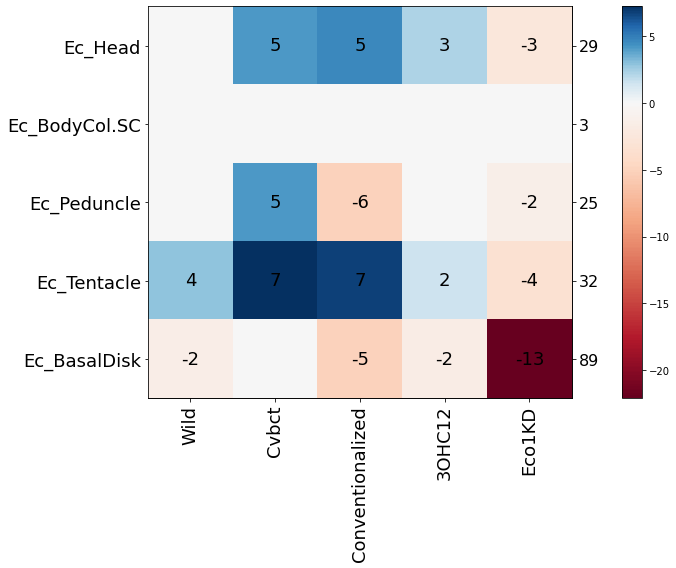

In [119]:
plot_heatmap_of_clusterings(ectoderm_statistic,ectoderm_pvalue,ectoderm_query,sliced_targets,
                            "Cell-Type specific gene expression between RNA-Seq experiments",
                           "Hydra vulgaris cell types", "Hydra vulgaris RNA-Seq experiments",
                            result_figure_path + "ectoderm_ttest.jpg",
                           size=(10,8),fonts=18, padx=0.09)

[*] Adjusting statistic values to pvalue ...
[*] Setting values with pval > 0.05 to 0 ...
[*] DONE pvalue adjustment
[*] Start plotting ...


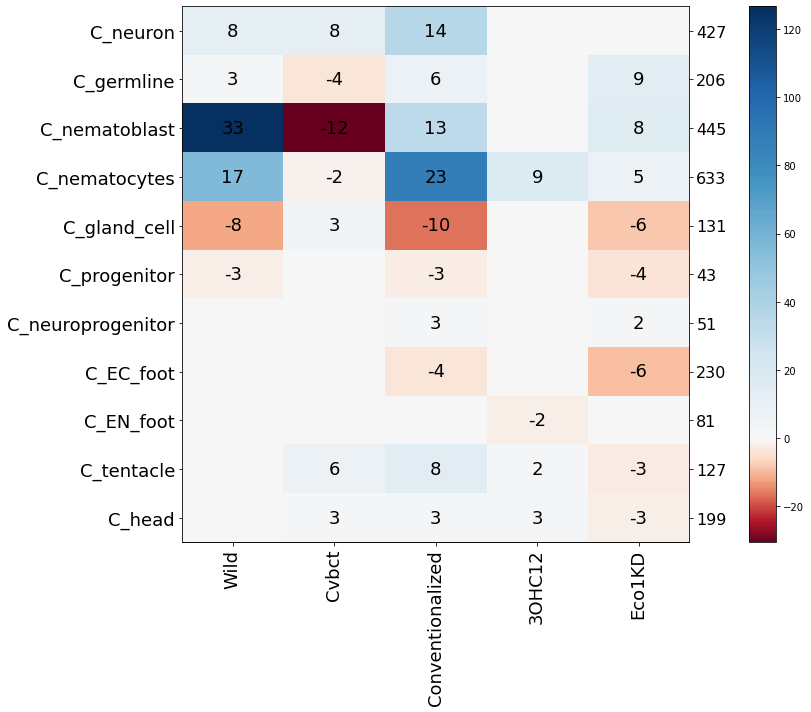

In [19]:
plot_heatmap_of_clusterings(supercluster_statistic,supercluster_pvalue,supercluster_query,sliced_targets,
                            "Cell-Type specific gene expression between RNA-Seq experiments",
                           "Hydra vulgaris cell types", "Hydra vulgaris RNA-Seq experiments",
                            result_figure_path + "supercluster_ttest.jpg",
                           size=(12,10),fonts=18, padx=0.09)

[*] Adjusting statistic values to pvalue ...
[*] Setting values with pval > 0.05 to 0 ...
[*] DONE pvalue adjustment
[*] Start plotting ...


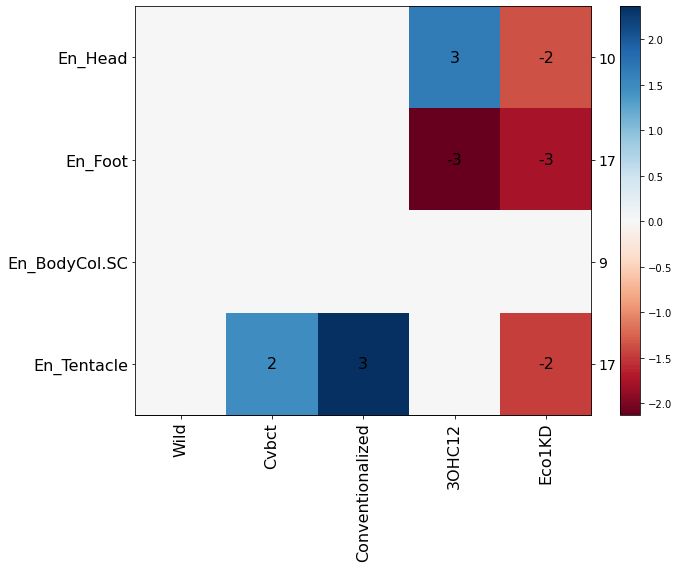

In [20]:
plot_heatmap_of_clusterings(endoderm_statistic,endoderm_pvalue,endoderm_query,sliced_targets,
                            "Cell-Type specific gene expression between RNA-Seq experiments",
                           "Hydra vulgaris cell types", "Hydra vulgaris RNA-Seq experiments",
                            result_figure_path + "endoderm_ttest.jpg",
                           size=(10,8),fonts=16)

[*] Adjusting statistic values to pvalue ...
[*] Setting values with pval > 0.05 to 0 ...
[*] DONE pvalue adjustment
[*] Start plotting ...


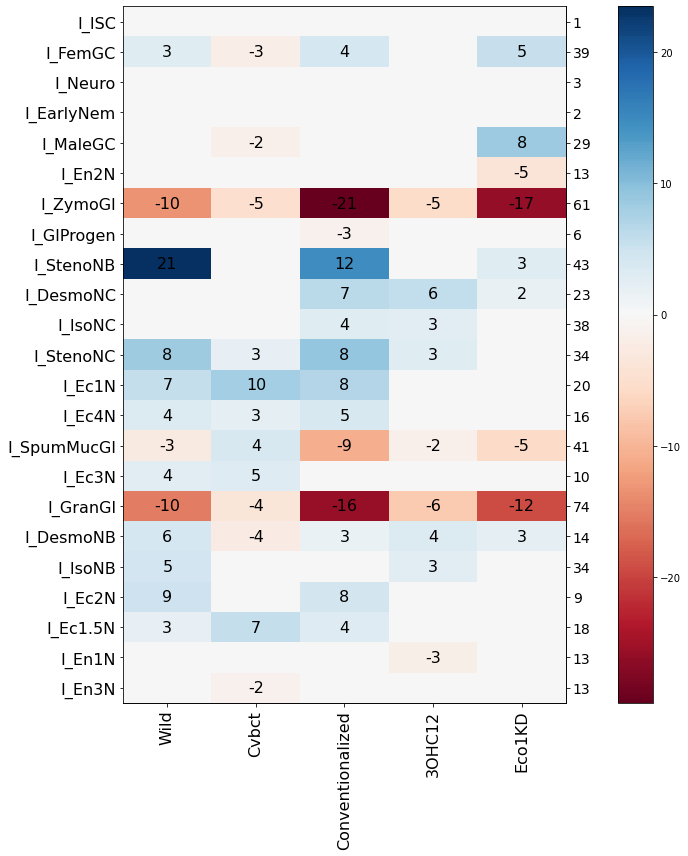

In [21]:
plot_heatmap_of_clusterings(interstitial_statistic,interstitial_pvalue,interstitial_query,sliced_targets,
                            "Cell-Type specific gene expression between RNA-Seq experiments",
                           "Hydra vulgaris cell types", "Hydra vulgaris RNA-Seq experiments",
                            result_figure_path + "interstitial_ttest.jpg",
                           size=(10,12),fonts=16, padx=0.09)

[*] Adjusting statistic values to pvalue ...
[*] Setting values with pval > 0.05 to 0 ...
[*] DONE pvalue adjustment
[*] Start plotting ...


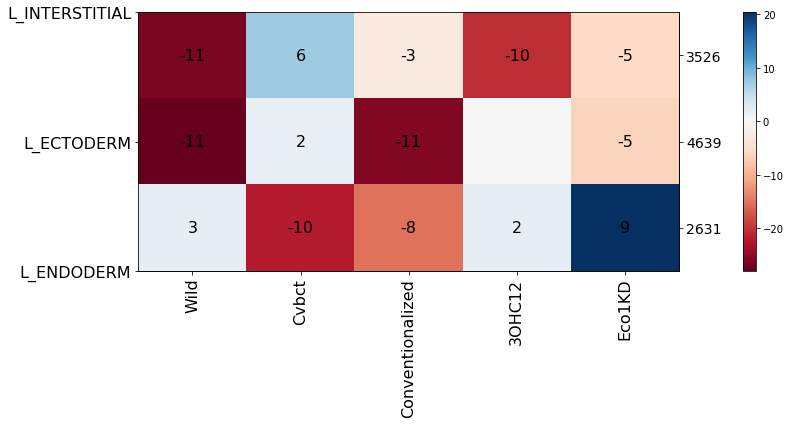

In [117]:
plot_heatmap_of_clusterings(l_supercluster_statistic,l_supercluster_pvalue,l_supercluster_query,sliced_targets,
                            "Cell-Type specific gene expression between RNA-Seq experiments",
                           "Hydra vulgaris cell types", "Hydra vulgaris RNA-Seq experiments",
                            result_figure_path + "l_supercluster_ttest.jpg",
                           size=(12,6),fonts=16, padx=0.09)

[*] Adjusting statistic values to pvalue ...
[*] Setting values with pval > 0.05 to 0 ...
[*] DONE pvalue adjustment
[*] Start plotting ...


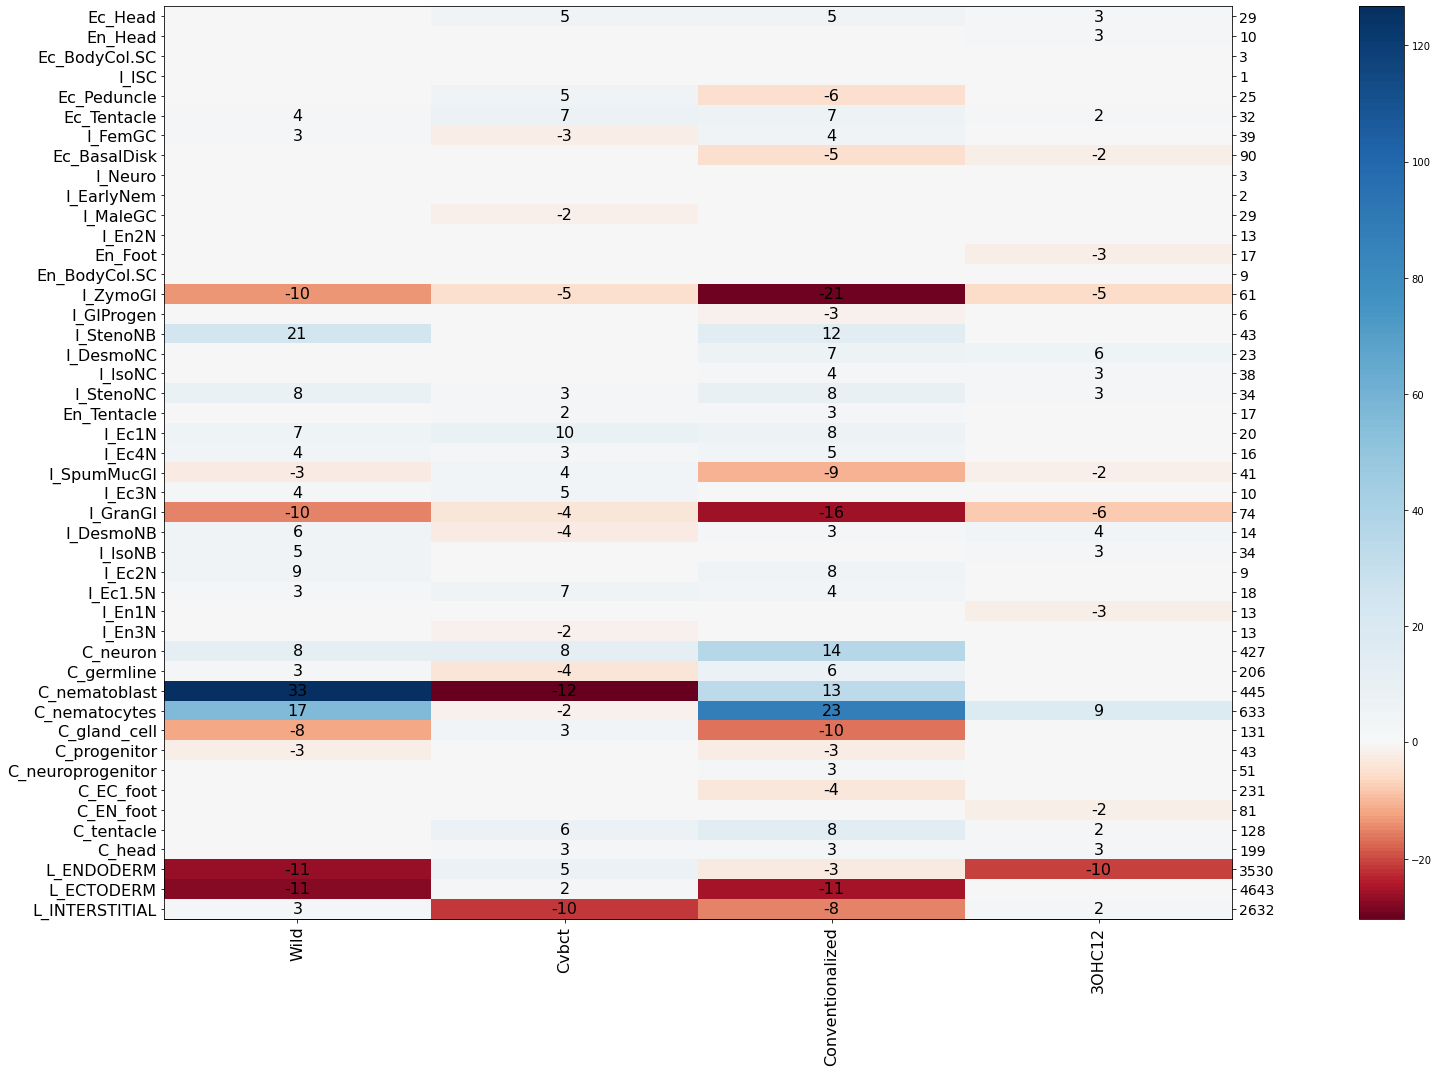

In [18]:
plot_heatmap_of_clusterings(statistic[cols],pvalue[cols],query_number,target_number,
                            "Cell-Type specific gene expression between RNA-Seq experiments",
                           "Hydra vulgaris cell types", "Hydra vulgaris RNA-Seq experiments",
                            result_figure_path + "test.jpg",
                           size=(22,15),fonts=16, padx=0.09)